Problema Max Cut para el grafo con aristas: 0-1,1-2

# Definición funciones QAOA

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit,transpile
from numpy import pi
from qiskit_aer import AerSimulator


def agrega_bloque_cost_mix(circuit,gama,beta,qreg_q):
    circuit.rzz(gama, qreg_q[0], qreg_q[1])
    circuit.rzz(gama, qreg_q[1], qreg_q[2])

    circuit.rx(beta, qreg_q[0])
    circuit.rx(beta, qreg_q[1])
    circuit.rx(beta, qreg_q[2])
    return circuit

def qaoa_circuit(gamas,betas,n):
    qreg_q = QuantumRegister(3, 'q')
    creg_c = ClassicalRegister(3, 'c')  
    circuit = QuantumCircuit(qreg_q,creg_c)
    if len(gamas)!=n or len(betas)!=n:
        print("invalido")
        return
    
    #Superposition
    circuit.h(qreg_q)
    
    for i in range (n):
        circuit=agrega_bloque_cost_mix(circuit,gamas[i],betas[i],qreg_q)
        
    circuit.measure(qreg_q, creg_c)

    return circuit



def evalua_circuito(gamas=[pi/2],betas=[pi/2],n=1,total_shots=1000,resultados_esperados=["101","010"]):
    simulator = AerSimulator()
    qc=qaoa_circuit(gamas,betas,n)

    # Transpile the circuit for the simulator
    compiled_circuit = transpile(qc, simulator)

    # Run the circuit
    job = simulator.run(compiled_circuit, shots=total_shots)

    # Get results
    result = job.result()
    counts = result.get_counts(compiled_circuit)
    proba_objective_res=0
    
    for pat in resultados_esperados:
        proba_objective_res+=counts.get(pat, 0) / total_shots

    
    return  proba_objective_res,counts


In [22]:
def imprimir_counts(counts):
    import matplotlib.pyplot as plt

    # counts es un dict tipo {'000': 120, '101': 350, ...}
    states = list(counts.keys())
    values = list(counts.values())

    plt.figure()
    plt.bar(states, values)

    plt.xlabel("Estados")
    plt.ylabel("Frecuencia")
    plt.title("Resultados de QAOA (counts)")

    plt.show()
        


## Prueba

In [ ]:
gamas=[pi/2,3*pi/4]
betas=[pi/2,0]
respuesta_correcta=["101","010"]
capas=2
t_shots=1000
proba,counts=evalua_circuito(gamas=gamas,betas=betas,n=capas,total_shots=t_shots,resultados_esperados=respuesta_correcta)

# Grid search para gamas y betas

In [30]:
import numpy as np
from itertools import product

def grid_search(n_capas=1, pasos=10, total_shots=1000):
    mejores = []
    mejor_proba = -1

    # valores posibles
    gamas_vals = np.linspace(0, np.pi, pasos)
    betas_vals = np.linspace(np.pi, 0, pasos)

    # todas las combinaciones posibles
    for gamas in product(gamas_vals, repeat=n_capas):
        for betas in product(betas_vals, repeat=n_capas):

            proba, _ = evalua_circuito(
                gamas=list(gamas),
                betas=list(betas),
                n=n_capas,
                total_shots=total_shots
            )

            if proba > mejor_proba:
                mejor_proba = proba
                mejores = [(list(gamas), list(betas))]

            elif abs(proba - mejor_proba) < 1e-6:
                mejores.append((list(gamas), list(betas)))

    return mejor_proba, mejores

# Prueba

In [32]:
mejor_proba, mejores=grid_search(n_capas=1,pasos=10,total_shots=1000)
print(mejor_proba)
print(mejores)

0.701
[([np.float64(1.0471975511965976)], [np.float64(2.0943951023931957)])]


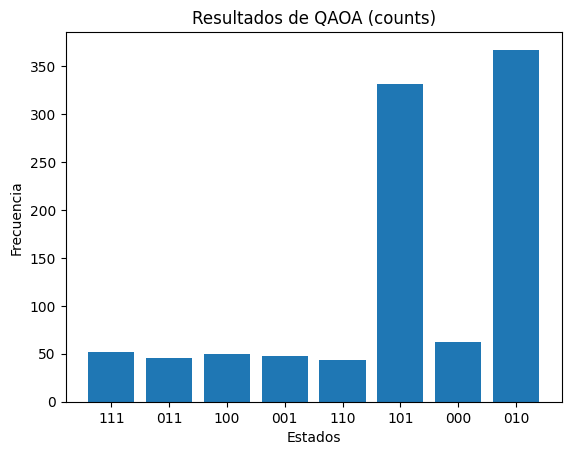

In [34]:
respuesta_correcta=["101","010"]
capas=1
t_shots=1000
gamas=[mejores[0][0][0]]
betas=[mejores[0][1][0]]
proba,counts=evalua_circuito(gamas=gamas,betas=betas,n=capas,total_shots=t_shots,resultados_esperados=respuesta_correcta)
imprimir_counts(counts)